# Feature epxloration (pensando en posuble modelado post-streamlit y que de aquí pueden salir gráficas y KPIs interesantes)

1. Hay una evidente relación entre día de la semana, hora y ATD
2. La distancia intuitivamente afecta aunque aquí no me haya metido en mucho mayor detalle en ella
3. Categorizar a los conductores parece una buena estrategia
4. No decido aún que hacer con los NANs
5. Flujo de repartidor es otra variable que claramente afecta
6. No queda muy clara la relación entre geo_archetype y ATD, pero hay demasiada varianza 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns

import logging
from pathlib import Path
from typing import Dict, List, Tuple

In [9]:
df = pd.read_csv("../data/raw/BC_A&A_with_ATD.csv")
timestamp_cols = [
'restaurant_offered_timestamp_utc',
'order_final_state_timestamp_local',
'eater_request_timestamp_local'
]

for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['restaurant_offered_timestamp_local'] = df['restaurant_offered_timestamp_utc'].dt.tz_localize('UTC').dt.tz_convert('America/Mexico_City')
df['eater_request_timestamp_local'] = df['eater_request_timestamp_local'].dt.tz_localize('America/Mexico_City')
df['order_final_state_timestamp_local'] = df['order_final_state_timestamp_local'].dt.tz_localize('America/Mexico_City')

categorical_cols = [
    'region', 'territory', 'country_name', 'courier_flow',
    'geo_archetype', 'merchant_surface'
]

df["courier_flow"].fillna("Unknown", inplace=True)

df[categorical_cols] = df[categorical_cols].astype('category')

uuid_cols = ['workflow_uuid', 'driver_uuid', 'delivery_trip_uuid']
df[uuid_cols] = df[uuid_cols].astype(str)

numeric_cols = ['pickup_distance', 'dropoff_distance']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.replace('\\N', np.nan, inplace=True)

df['date'] = df['eater_request_timestamp_local'].dt.date
df['hour'] = df['eater_request_timestamp_local'].dt.hour
df['day_of_week'] = df['eater_request_timestamp_local'].dt.day_of_week
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df["driver_uuid"].fillna("Unassigned", inplace=True)

df['geo_archetype'] = df['geo_archetype'].replace('Defend CP', 'Defend_CP')

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_50307/505601991.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["courier_flow"].fillna("Unknown", inplace=True)
/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_50307/505601991.py:30: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.replace

In [491]:
df['ATD_log'] = np.log1p(df['ATD'].fillna(0))
df['ATD_winsor'] = df['ATD'].clip(lower=df['ATD'].quantile(0.01), upper=df['ATD'].quantile(0.99))

In [492]:
if "restaurant_offered_timestamp_local" in df.columns:
    df["rest_offer_missing"] = df["restaurant_offered_timestamp_local"].isna().astype(int)

for col in ["pickup_distance", "dropoff_distance"]:
    
    nan_flag = f"{col}_nan"
    df[nan_flag] = df[col].isna().astype(int)
    
    
    df[col] = df.groupby(["territory", "day_of_week", "hour"])[col].transform(lambda s: s.fillna(s.mean()))
    
    df[col].fillna(df[col].median(), inplace=True)

/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_2606/2518630157.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(["territory", "day_of_week", "hour"])[col].transform(lambda s: s.fillna(s.mean()))
/var/folders/mk/_ghzwf3j0hvf_yvj29dkl4lh0000gn/T/ipykernel_2606/2518630157.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the o

1. Hay una evidente relación entre día de la semana, hora y ATD

Hay que tener horario con los días y horas, porque como los tengo, implica distancias 1 entre 22 y 23 pero 23 entre 23 y 0, cuando son adyacentes.

Si no, segfuro habrán saltos entre 23-0 que podemos aprender con árboles de decisión a costa de la interpretabilidad

In [493]:
df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

Vamos a meter también la hora pico por ordenes y por ATD (empiricamente) y la hora en bins, para probar 

In [494]:
#primer por ordenes
ordenes_por_hora = df.groupby('hour')['ATD'].size()
hora_pico_ordenes = ordenes_por_hora.idxmax()    

inicio_hpo = (hora_pico_ordenes - 2) % 24
fin_hpo = (hora_pico_ordenes + 2) % 24

print(inicio_hpo, '-', fin_hpo)

# ahora hora pico por ATD
atd_por_hora = df.groupby('hour')['ATD'].mean()
hora_pico_atd = atd_por_hora.idxmax()    

inicio_hpa = (hora_pico_atd - 2) % 24
fin_hpa = (hora_pico_atd + 2) % 24

print(inicio_hpa, '-', fin_hpa)

df['hora_pico_ordenes'] = df['hour'].between(inicio_hpo, fin_hpo).astype(int)
df['hora_pico_atd'] = df['hour'].between(inicio_hpa, fin_hpa).astype(int)

12 - 16
3 - 7


In [495]:
df.groupby('hora_pico_atd')['ATD'].mean()

hora_pico_atd
0    40.006791
1    55.716443
Name: ATD, dtype: float64

In [496]:
df.groupby('hora_pico_ordenes')['ATD'].mean()

hora_pico_ordenes
0    41.34604
1    38.44800
Name: ATD, dtype: float64

In [497]:
def bin_hours(hour):
    if hour < 4:
        return '00-04'
    elif hour < 8:
        return '04-08'
    elif hour < 12:
        return '08-12'
    elif hour < 16:
        return '12-16'
    elif hour < 20:
        return '16-20'
    else:
        return '20-24'
    
df['hour_bin'] = df['hour'].apply(bin_hours)
df.groupby('hour_bin')['ATD'].mean()

hour_bin
00-04    60.428353
04-08    53.194847
08-12    37.579152
12-16    38.400569
16-20    40.105345
20-24    44.228197
Name: ATD, dtype: float64

2. La distancia intuitivamente afecta 


In [498]:
for col in ["pickup_distance", "dropoff_distance"]:
    df[f"{col}_log"] = np.log1p(df[col])

df["pickup_dropoff_ratio"] = (
    df["pickup_distance_log"] / df["dropoff_distance_log"]
).replace([np.nan, np.inf, -np.inf], 1)

Dummies

In [499]:
df = pd.get_dummies(df, columns=["courier_flow"], prefix="courier", drop_first=True)
df = pd.get_dummies(df, columns=["geo_archetype"], prefix="geo", drop_first=True)
df = pd.get_dummies(df, columns=["merchant_surface"], prefix="surface", drop_first=True)
df = pd.get_dummies(df, columns=["region"], prefix="region", drop_first=True)
df = pd.get_dummies(df, columns=["territory"], prefix="territory", drop_first=True)

In [500]:
df['driver_uuid'].value_counts()

driver_uuid
Unassigned                              12550
32b8c3c5-ed5f-4109-be6d-8fc79e884a05       95
05863fc3-bbdb-498f-b9d4-f363758b122f       88
c375fe77-7626-4926-89ca-664e6d25c0be       88
be7b8044-0cf0-4037-8b97-a92ed9231772       86
                                        ...  
5c5e9504-8068-4ca9-a2a6-f951f7b443f9        1
640f4367-fd29-4d06-bff0-479babd38eee        1
396fc23c-834d-4e9e-ad76-9ae2280d8689        1
50a82946-5b87-43b2-a8fe-5f7147a51269        1
0911f042-f220-457e-ab2a-214aee75c858        1
Name: count, Length: 91214, dtype: int64

In [501]:
tiene_driver = df["driver_uuid"] != "Unassigned"
driver_counts = df.loc[tiene_driver, "driver_uuid"].value_counts()

buckets = ["novice", "low", "medium", "high", "expert"]
driver_bucket = pd.qcut(driver_counts, q=5, labels=buckets)

bucket_map = driver_bucket.to_dict()

def assign_bucket(uuid):
    if uuid == "Unassigned":
        return "unassigned"
    return bucket_map.get(uuid, "novice")

df["driver_orders_category"] = df["driver_uuid"].map(assign_bucket)

In [509]:
df.groupby(['driver_uuid', 'driver_orders_category']).size().reset_index().sort_values(by=0, ascending=False).groupby('driver_orders_category')[0].mean().sort_values(ascending=False)

driver_orders_category
unassigned    12550.000000
expert           30.686276
high             13.843005
medium            6.737770
low               3.451580
novice            1.374364
Name: 0, dtype: float64

Por eficiencia, lo que haré es definir los siguientes buckets
novato = 0 - 4 viajes
bajo = 4 - 7 viajes
medio = 7 - 14 viajes
alto = 14 - 30 viajes
experto = +30 viajes 

In [460]:
df.groupby(["driver_orders_category"])["ATD"].mean()

driver_orders_category
expert        37.091657
high          42.442576
low           43.642900
medium        43.918088
novice        45.488172
unassigned    60.099420
Name: ATD, dtype: float64

Feature selection, estudiando varianzas, outliers, correlaciones, etc.

In [461]:
tol_var= 1e-3 

In [462]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.columns.difference(numeric_cols).tolist()

HAcemos primero lo que básicamente es un boxplot con extra steps pero que permite meterse con mayor detale a la composición de la data

In [463]:
desc = (df[numeric_cols].agg(["count","mean","std","min",
                              lambda x: x.quantile(0.01),
                              lambda x: x.quantile(0.05),
                              "median", lambda x: x.quantile(0.95),
                              lambda x: x.quantile(0.99),
                              "max","skew"]).T)
desc.columns = ['count', 'mean', 'std', 'min', 'p01', 'p05', 'median', 'p95', 'p99',
       'max', 'skew']
desc["varianza_aprox_cero"] = (desc["std"]**2 < tol_var)

In [464]:
desc

,count,mean,std,min,p01,p05,median,p95,p99,max,skew,varianza_aprox_cero
pickup_distance,1000000.0,1.522533,1.581937,0.000000,0.000000,0.000000,1.132000,4.642000,7.181000,43.161000,1.956369,False
dropoff_distance,1000000.0,4.108121,3.128116,0.000000,0.000000,0.530000,3.372000,10.246000,14.531000,123.586000,1.602480,False
ATD,1000000.0,40.170769,62.754198,0.000000,10.216667,16.016667,33.933333,71.566667,112.233333,8515.700000,44.882031,False
hour,1000000.0,15.218664,4.114953,0.000000,3.000000,9.000000,15.000000,21.000000,23.000000,23.000000,-0.493996,False
day_of_week,1000000.0,3.444592,2.035067,0.000000,0.000000,0.000000,4.000000,6.000000,6.000000,6.000000,-0.320955,False
is_weekend,1000000.0,0.389734,0.487690,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.452198,False
ATD_log,1000000.0,3.553742,0.510132,0.000000,2.417401,2.834193,3.553441,4.284506,4.729451,9.049784,0.006353,False
ATD_winsor,1000000.0,37.564113,17.995692,10.216667,10.216667,16.016667,33.933333,71.566667,112.233333,112.233333,1.462998,False
rest_offer_missing,1000000.0,0.000165,0.012844,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,77.830742,True
pickup_distance_nan,1000000.0,0.012847,0.112614,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,8.651729,False


Vemos algunas variables con muy claros outliers (ej: max de 8515 en ATD), incluso con valores muy altos para el percentil 99. Además, suelen ser variables con altísimo skewness lo cuál puede ser problemático trabajando inlcuso en arboles.


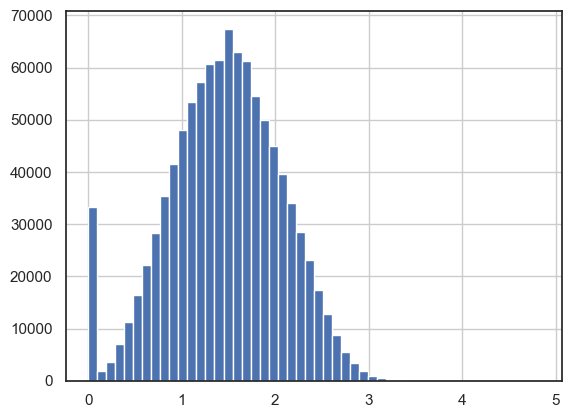

<Axes: >

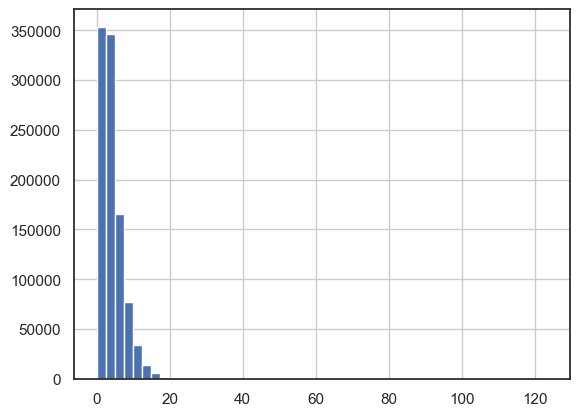

In [465]:
np.log1p(df['dropoff_distance']).hist(bins = 50)
plt.show()

df['dropoff_distance'].hist(bins = 50)

Arriba y abajo vemos que conviene utilizar logs porque con las colas largas los valores más grandes dominarán el gradiente y entonces ese top % dominará la función de pérdida.
N o deseable. 

En la caso del predictor (arriba), no es vital, pero no está de más sobre todo una distribución tan sesgada como la original

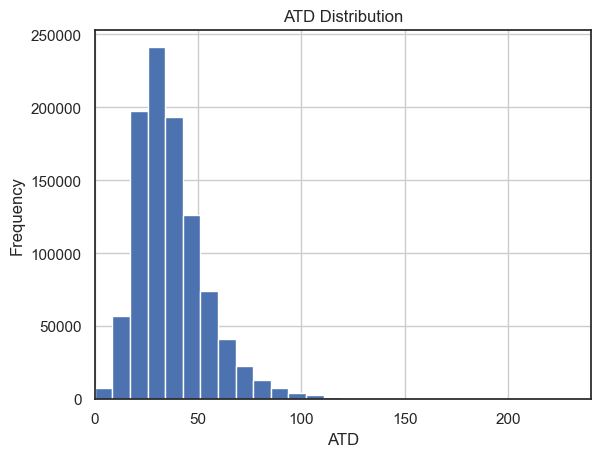

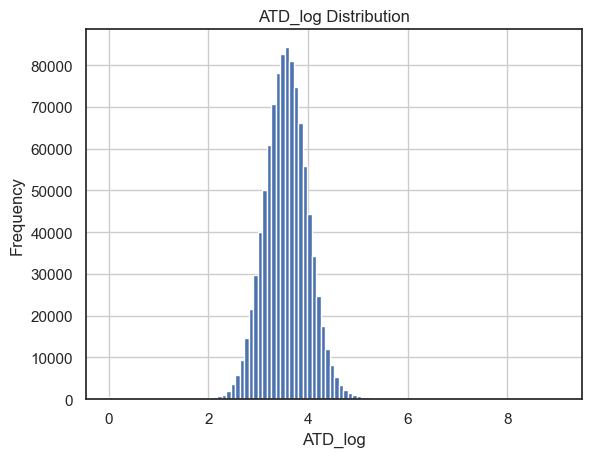

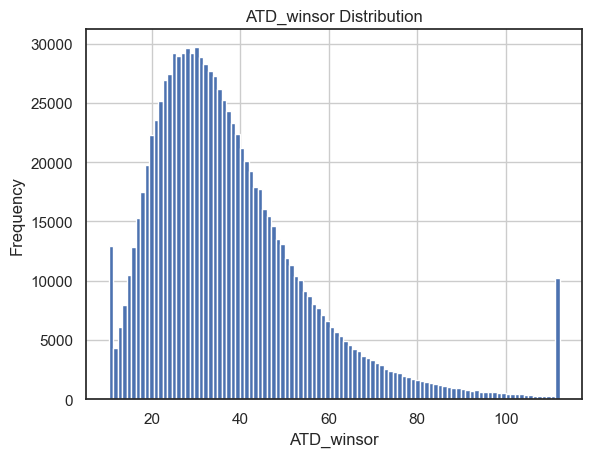

In [466]:
df['ATD'].hist(bins=1000)
plt.title("ATD Distribution")
plt.xlabel("ATD")
plt.ylabel("Frequency")
plt.xlim(0,240)
plt.show()

(df['ATD_log']).hist(bins=100)
plt.title("ATD_log Distribution")
plt.xlabel("ATD_log")
plt.ylabel("Frequency")
plt.show()

df['ATD_winsor'].hist(bins=100)
plt.title("ATD_winsor Distribution")
plt.xlabel("ATD_winsor")
plt.ylabel("Frequency")
plt.show()

En términos de correlación, no hace sentido quedarnos con pickup_distance_nan y dropoff_distance_nan, quitamos una de las dos porque esencialmente representan lo mismo.

Lo mismo con las distancias, conviene quedarse con ambas distancias transformadas con log.

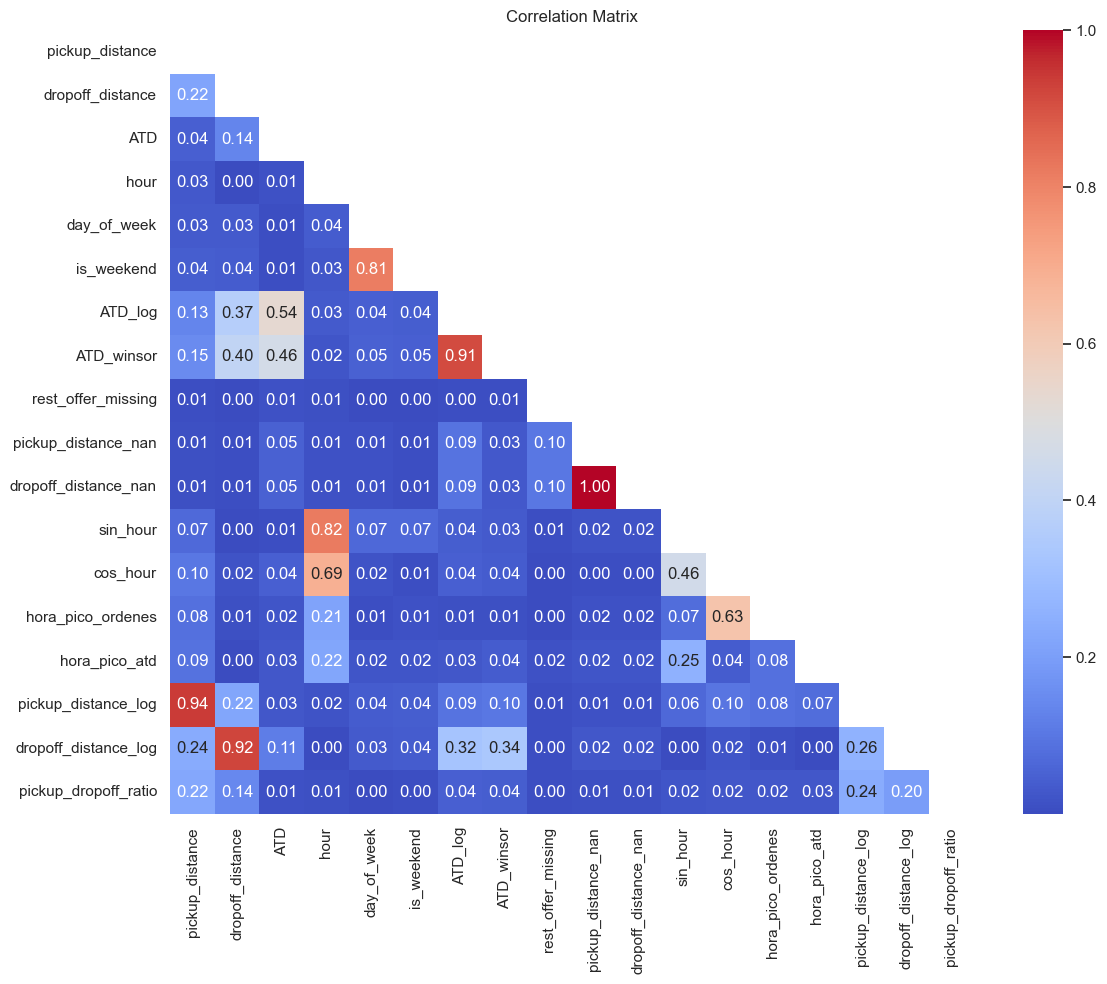

In [467]:
corr = df[numeric_cols].corr().abs()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True,fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [468]:
df['pickup_dropoff_ratio'].describe()

count    1000000.000000
mean           0.644043
std            1.466068
min            0.000000
25%            0.250742
50%            0.541747
75%            0.851566
max          408.533409
Name: pickup_dropoff_ratio, dtype: float64

<Axes: >

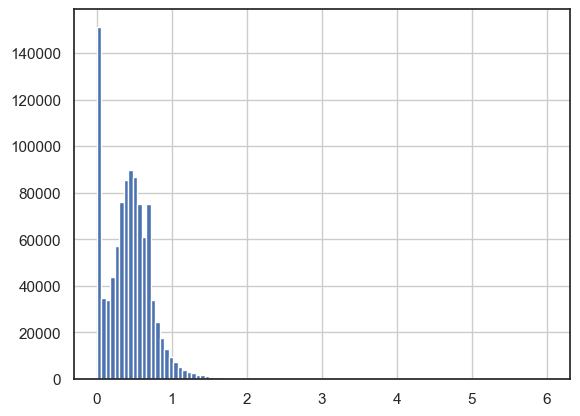

In [469]:
df['pickup_dropoff_ratio_log'] = np.log1p(df['pickup_dropoff_ratio'])
df['pickup_dropoff_ratio_log'].hist(bins=100)

<Axes: >

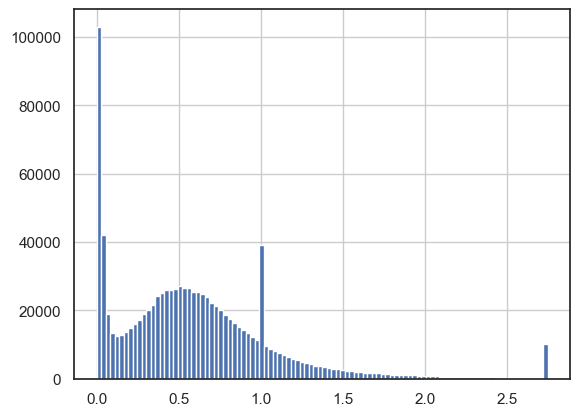

In [470]:
df['pickup_dropoff_ratio_winsor'] = (df['pickup_dropoff_ratio'].clip(lower=df['pickup_dropoff_ratio'].quantile(0.01),
                                                                         upper=df['pickup_dropoff_ratio'].quantile(0.99)))

df['pickup_dropoff_ratio_winsor'].hist(bins=100)

<Axes: >

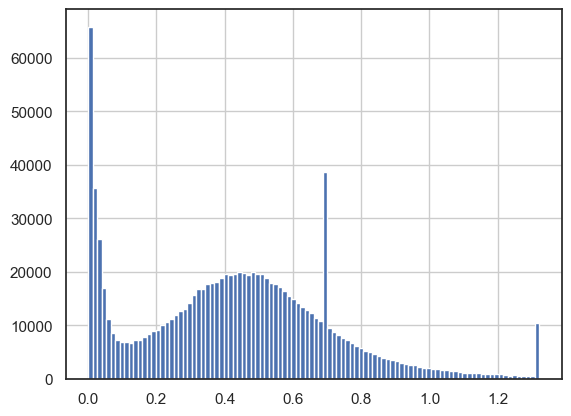

In [471]:
# log1p y luego winsorizar p99.5 es equivalente a winsorizar p99 y luego aplicar log1p
df['pickup_dropoff_ratio_winsor_log'] = np.log1p(df['pickup_dropoff_ratio'].clip(lower=df['pickup_dropoff_ratio'].quantile(0.01),
                                                                                    upper=df['pickup_dropoff_ratio'].quantile(0.99)))

df['pickup_dropoff_ratio_winsor_log'].hist(bins=100)

Mucho más prometedor hacer ambas trasnformaciones que una u otra

In [472]:
df.columns

Index(['country_name', 'workflow_uuid', 'driver_uuid', 'delivery_trip_uuid',
       'restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local',
       'eater_request_timestamp_local', 'pickup_distance', 'dropoff_distance',
       'ATD', 'restaurant_offered_timestamp_local', 'date', 'hour',
       'day_of_week', 'is_weekend', 'ATD_log', 'ATD_winsor',
       'rest_offer_missing', 'pickup_distance_nan', 'dropoff_distance_nan',
       'sin_hour', 'cos_hour', 'hora_pico_ordenes', 'hora_pico_atd',
       'hour_bin', 'pickup_distance_log', 'dropoff_distance_log',
       'pickup_dropoff_ratio', 'courier_Logistics', 'courier_Motorbike',
       'courier_Onboarder', 'courier_SUV', 'courier_UberEats', 'courier_UberX',
       'geo_Defend_CP', 'geo_Drive momentum', 'geo_Play offense',
       'geo_Unlaunched', 'geo_Unspecified', 'surface_POS', 'surface_Tablet',
       'surface_Unspecified', 'surface_Web/Mobile',
       'territory_Long Tail - Region', 'territory_North',
       'territory_

Voy a probar pequeños modelos para ver si sistematicamente podemos decidir los features.

Para empezar algunas cosas son clara.

drops = 'country_name', 'workflow_uuid', 'driver_uuid', 'delivery_trip_uuid',
       'restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local',
       'eater_request_timestamp_local', 'pickup_distance', 'dropoff_distance',
       'ATD', 'restaurant_offered_timestamp_local', 'date', 'ATD_winsor',
        'dropoff_distance_nan',
       'pickup_dropoff_ratio',
       'pickup_dropoff_ratio_log', 'pickup_dropoff_ratio_winsor'

quedarme = 'hour',
       'day_of_week', 'is_weekend', 'ATD_log', 'rest_offer_missing', 'pickup_distance_nan',
       'sin_hour', 'cos_hour', 'hora_pico_ordenes', 'hora_pico_atd',
       'hour_bin', 'pickup_distance_log', 'dropoff_distance_log','courier_Logistics', 'courier_Motorbike',
       'courier_Onboarder', 'courier_SUV', 'courier_UberEats', 'courier_UberX',
       'geo_Defend CP', 'geo_Drive momentum', 'geo_Play offense',
       'geo_Unlaunched', 'geo_Unspecified', 'surface_POS', 'surface_Tablet',
       'surface_Unspecified', 'surface_Web/Mobile',
       'territory_Long Tail - Region', 'territory_North',
       'territory_South East', 'territory_West', 'driver_orders_category', 'pickup_dropoff_ratio_winsor_log'

# Pruebas de features

In [473]:
drops = ['country_name', 'workflow_uuid', 'driver_uuid', 'delivery_trip_uuid',
       'restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local',
       'eater_request_timestamp_local', 'pickup_distance', 'dropoff_distance',
       'ATD', 'restaurant_offered_timestamp_local', 'date', 'ATD_winsor',
        'dropoff_distance_nan',
       'pickup_dropoff_ratio',
       'pickup_dropoff_ratio_log', 'pickup_dropoff_ratio_winsor']

df_prep = df.drop(columns=drops, inplace=False, errors='ignore')

In [474]:
df_prep.columns

Index(['hour', 'day_of_week', 'is_weekend', 'ATD_log', 'rest_offer_missing',
       'pickup_distance_nan', 'sin_hour', 'cos_hour', 'hora_pico_ordenes',
       'hora_pico_atd', 'hour_bin', 'pickup_distance_log',
       'dropoff_distance_log', 'courier_Logistics', 'courier_Motorbike',
       'courier_Onboarder', 'courier_SUV', 'courier_UberEats', 'courier_UberX',
       'geo_Defend_CP', 'geo_Drive momentum', 'geo_Play offense',
       'geo_Unlaunched', 'geo_Unspecified', 'surface_POS', 'surface_Tablet',
       'surface_Unspecified', 'surface_Web/Mobile',
       'territory_Long Tail - Region', 'territory_North',
       'territory_South East', 'territory_West', 'driver_orders_category',
       'pickup_dropoff_ratio_winsor_log'],
      dtype='object')

In [475]:
df_prep = pd.get_dummies(df_prep, columns=["hour_bin", "driver_orders_category"], drop_first=True)

In [481]:
df_prep.to_csv("../data/processed/BC_A&A_with_ATD_prep.csv", index=False)

In [513]:
df.columns

Index(['region', 'territory', 'country_name', 'workflow_uuid', 'driver_uuid',
       'delivery_trip_uuid', 'courier_flow',
       'restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local',
       'eater_request_timestamp_local', 'geo_archetype', 'merchant_surface',
       'pickup_distance', 'dropoff_distance', 'ATD',
       'restaurant_offered_timestamp_local', 'date', 'hour', 'day_of_week',
       'is_weekend'],
      dtype='object')

In [1]:
df.columns

NameError: name 'df' is not defined